#### STEP 1: Loading Dependencies

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, f_oneway

df = pd.read_csv("../data/processed/cleaned_healthcare.csv")

#### STEP 2: Data Cleaning

In [2]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

Dataset shape: (54966, 15)

Column names:
['name', 'age', 'gender', 'blood_type', 'medical_condition', 'date_of_admission', 'doctor', 'hospital', 'insurance_provider', 'billing_amount', 'room_number', 'admission_type', 'discharge_date', 'medication', 'test_results']

First five rows:


,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
# Investigate target variable

target = "test_results"

print("Target distribution:")
display(df[target].value_counts())

print("\nTarget proportions:")
display(df[target].value_counts(normalize=True).round(4))


Target distribution:


test_results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64


Target proportions:


test_results
Abnormal        0.3354
Normal          0.3335
Inconclusive    0.3311
Name: proportion, dtype: float64


Missing target values: 0


In [12]:

# 1. Check data types
print("DATA TYPES")
display(df.dtypes.to_frame(name="data_type"))

# 2. Check missing values
print("\nMISSING VALUES")
missing = df.isna().sum()
display(
    missing[missing > 0]
    .sort_values(ascending=False)
    .to_frame(name="missing_count")
)

# 3. Check duplicate rows
print("\nDUPLICATE ROWS")
print("Exact duplicate rows:", df.duplicated().sum())

# 4. Inspect categorical cardinality
print("\nUNIQUE VALUES IN CATEGORICAL COLUMNS")
categorical_cols = df.select_dtypes(include="str").columns

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()}")


DATA TYPES


,data_type
name,str
age,int64
gender,str
blood_type,str
medical_condition,str
date_of_admission,datetime64[us]
doctor,str
hospital,str
insurance_provider,str
billing_amount,float64



MISSING VALUES


,missing_count
billing_amount,106



DUPLICATE ROWS
Exact duplicate rows: 0

UNIQUE VALUES IN CATEGORICAL COLUMNS
name: 40235
gender: 2
blood_type: 8
medical_condition: 6
doctor: 40341
hospital: 39876
insurance_provider: 5
admission_type: 3
medication: 5
test_results: 3


In [14]:
# Date preprocessing

# Step 1: Convert date columns to datetime
date_cols = ["date_of_admission", "discharge_date"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Step 3: Check for missing or invalid dates
print("\nMISSING OR INVALID DATES")
display(df[date_cols].isna().sum().to_frame(name="missing_count"))

# Step 4: Check for impossible discharge dates
negative_stays = df["discharge_date"] < df["date_of_admission"]

print("\nDISCHARGE BEFORE ADMISSION")
print("Records:", negative_stays.sum())



MISSING OR INVALID DATES


,missing_count
date_of_admission,0
discharge_date,0



DISCHARGE BEFORE ADMISSION
Records: 0


In [ ]:
##### FIXXXXXXX
# Calculate length of stay in days
df["length_of_stay"] = (
    df["discharge_date"] - df["date_of_admission"]
).dt.days

# Inspect the distribution
print("LENGTH OF STAY SUMMARY")
display(df["length_of_stay"].describe().to_frame())

# Check for zero-day stays
print("\nZERO-DAY STAYS")
print((df["length_of_stay"] == 0).sum())

# Check unusually long stays
print("\nSTAYS LONGER THAN 30 DAYS")
print((df["length_of_stay"] > 30).sum())


LENGTH OF STAY SUMMARY


,length_of_stay
count,54966.000000
mean,15.499290
std,8.661471
min,1.000000
25%,8.000000
50%,15.000000
75%,23.000000
max,30.000000



ZERO-DAY STAYS
0

STAYS LONGER THAN 30 DAYS
0


In [18]:

# Candidate features for the initial model
candidate_cols = [
    "age",
    "gender",
    "blood_type",
    "medical_condition",
    "insurance_provider",
    "admission_type",
    "medication",
]

print("NUMERIC FEATURE SUMMARY")
display(df[["age"]].describe())

print("\nCATEGORICAL FEATURE VALUES")

for col in candidate_cols:
    if col != "age":
        print(f"\n{col} ({df[col].nunique()})")
        print(sorted(df[col].dropna().unique()))


NUMERIC FEATURE SUMMARY


,age
count,54966.000000
mean,51.535185
std,19.605661
min,13.000000
25%,35.000000
50%,52.000000
75%,68.000000
max,89.000000



CATEGORICAL FEATURE VALUES

gender (2)
['Female', 'Male']

blood_type (8)
['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']

medical_condition (6)
['Arthritis', 'Asthma', 'Cancer', 'Diabetes', 'Hypertension', 'Obesity']

insurance_provider (5)
['Aetna', 'Blue Cross', 'Cigna', 'Medicare', 'UnitedHealthcare']

admission_type (3)
['Elective', 'Emergency', 'Urgent']

medication (5)
['Aspirin', 'Ibuprofen', 'Lipitor', 'Paracetamol', 'Penicillin']


In [ ]:

# Define features and target
feature_cols = [
    "age",
    "gender",
    "blood_type",
    "medical_condition",
    "insurance_provider",
    "admission_type",
    "medication",
]

target_col = "test_results"

X = df[feature_cols].copy()
y = df[target_col].copy()


AGE: DESCRIPTIVE STATISTICS


,age
count,54966.000000
mean,51.535185
std,19.605661
min,13.000000
25%,35.000000
50%,52.000000
75%,68.000000
max,89.000000


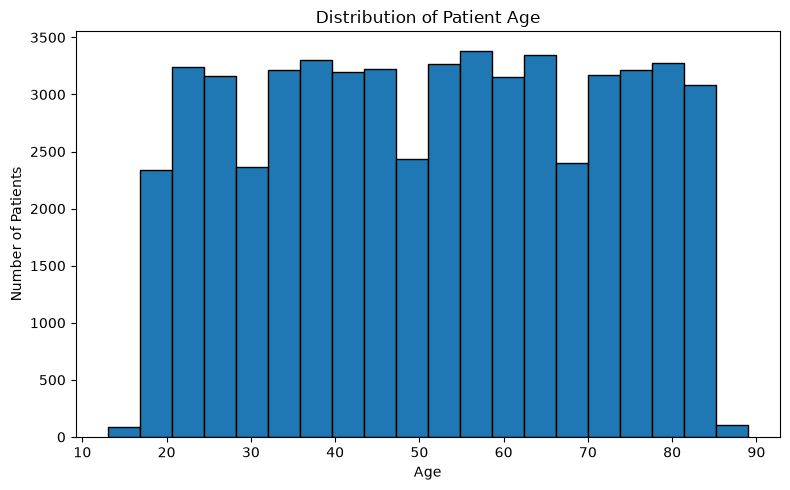

AGE BY TEST RESULT


,count,mean,median,std,min,max
test_results,,,,,,
Abnormal,18437,51.64,52.0,19.56,13,89
Inconclusive,18198,51.66,52.0,19.54,13,89
Normal,18331,51.31,51.0,19.71,13,89


<Figure size 800x500 with 0 Axes>

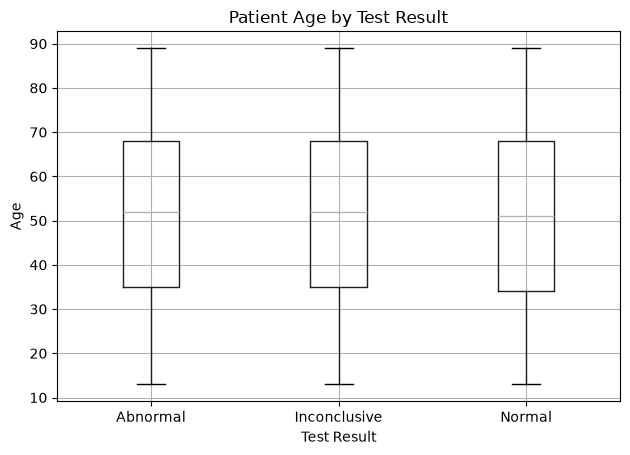

In [ ]:
# Descriptive statistics for age(numeric feature)
print("AGE: DESCRIPTIVE STATISTICS")
display(df["age"].describe().to_frame())

# Distribution of age
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=20, edgecolor="black")
plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

# Compare age across test-result classes
print("AGE BY TEST RESULT")
display(
    df.groupby("test_results")["age"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

# Compare age distributions visually
plt.figure(figsize=(8, 5))
df.boxplot(column="age", by="test_results")
plt.title("Patient Age by Test Result")
plt.suptitle("")
plt.xlabel("Test Result")
plt.ylabel("Age")
plt.tight_layout()
plt.show()


MEDICAL_CONDITION: TEST RESULT DISTRIBUTION (%)


test_results,Abnormal,Inconclusive,Normal
medical_condition,,,
Arthritis,34.24,33.22,32.55
Asthma,32.77,32.97,34.26
Cancer,33.80,33.18,33.02
Diabetes,33.97,32.81,33.21
Hypertension,32.53,33.53,33.94
Obesity,33.94,32.93,33.13


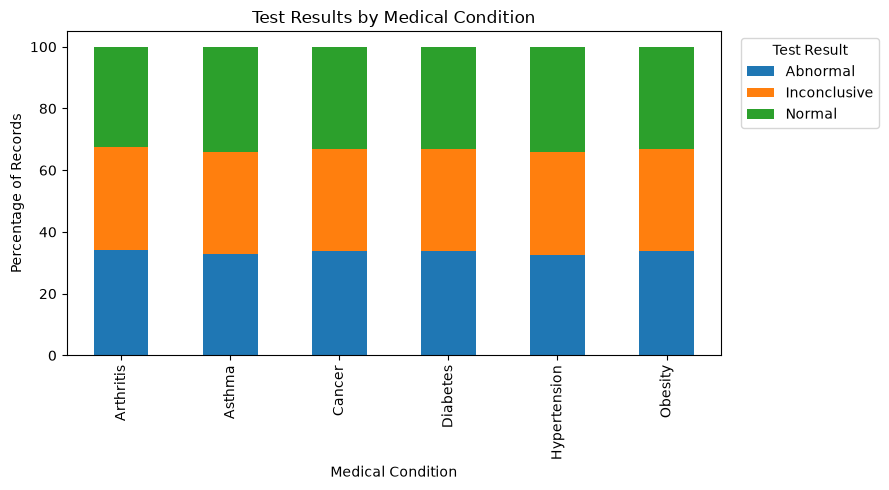


ADMISSION_TYPE: TEST RESULT DISTRIBUTION (%)


test_results,Abnormal,Inconclusive,Normal
admission_type,,,
Elective,33.74,32.77,33.49
Emergency,33.36,33.26,33.39
Urgent,33.53,33.30,33.17


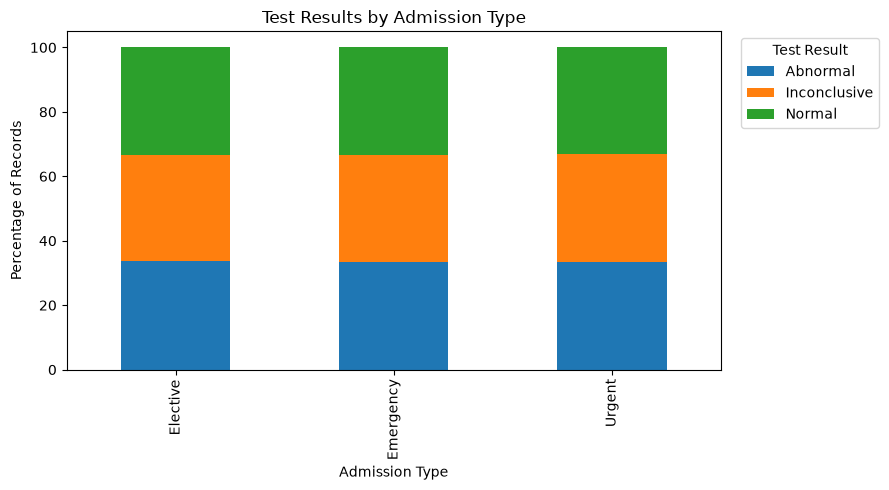


MEDICATION: TEST RESULT DISTRIBUTION (%)


test_results,Abnormal,Inconclusive,Normal
medication,,,
Aspirin,33.69,32.67,33.65
Ibuprofen,33.67,32.78,33.56
Lipitor,33.25,33.70,33.05
Paracetamol,33.70,33.25,33.05
Penicillin,33.42,33.14,33.44


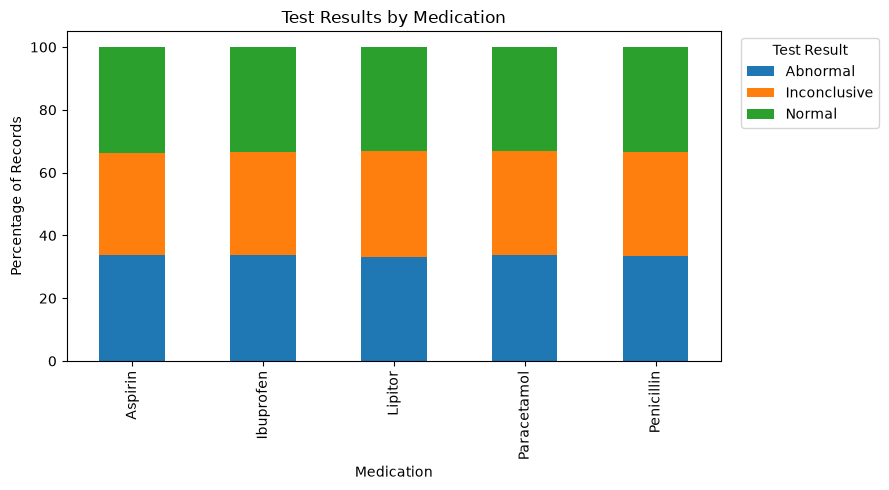


GENDER: TEST RESULT DISTRIBUTION (%)


test_results,Abnormal,Inconclusive,Normal
gender,,,
Female,33.66,33.28,33.05
Male,33.42,32.93,33.64


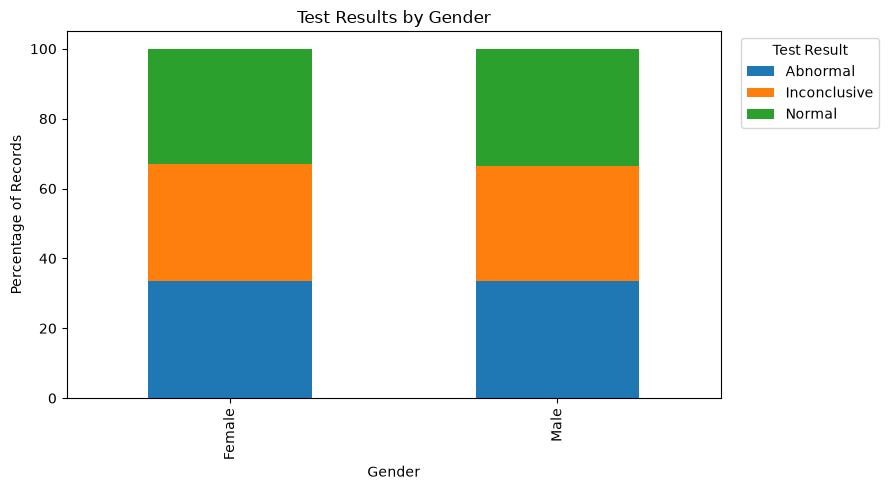


BLOOD_TYPE: TEST RESULT DISTRIBUTION (%)


test_results,Abnormal,Inconclusive,Normal
blood_type,,,
A+,33.56,33.47,32.98
A-,33.52,33.04,33.44
AB+,33.14,33.55,33.30
AB-,33.60,32.35,34.04
B+,33.13,34.12,32.75
B-,33.82,32.70,33.48
O+,33.93,32.71,33.36
O-,33.64,32.92,33.44


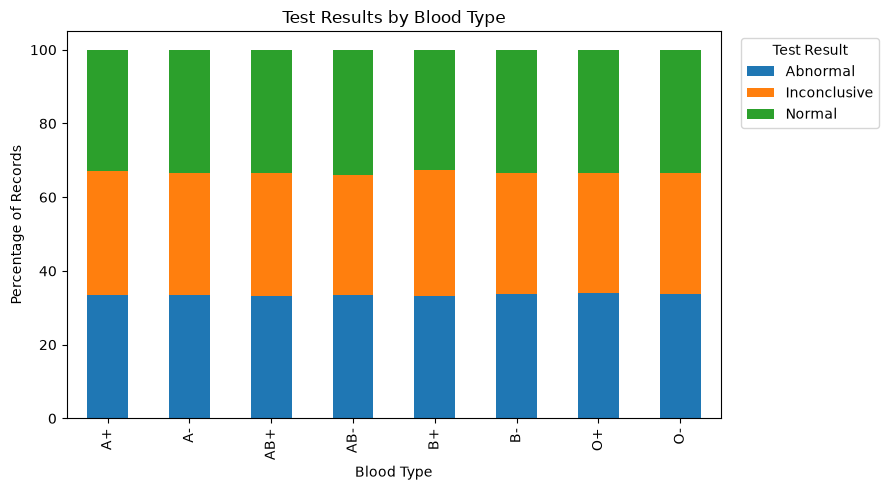


INSURANCE_PROVIDER: TEST RESULT DISTRIBUTION (%)


test_results,Abnormal,Inconclusive,Normal
insurance_provider,,,
Aetna,33.30,33.53,33.16
Blue Cross,32.79,33.81,33.40
Cigna,33.82,33.12,33.06
Medicare,33.90,32.80,33.30
UnitedHealthcare,33.89,32.29,33.82


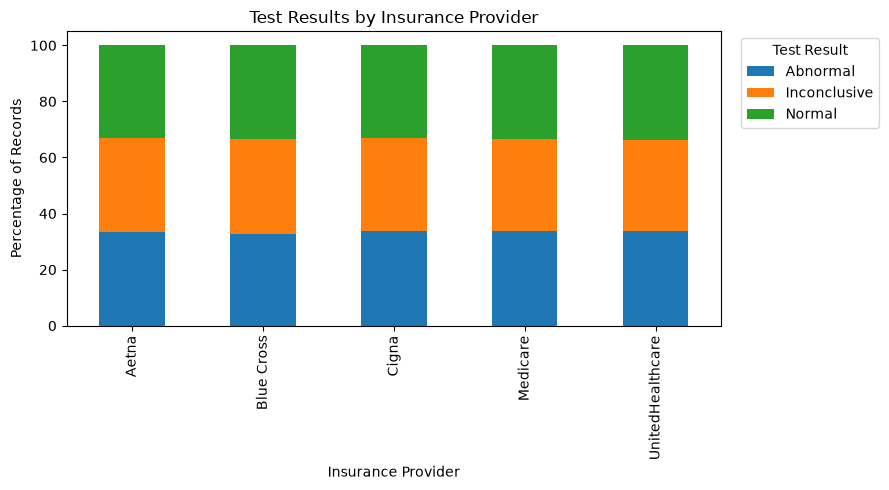

In [22]:

categorical_features = [
    "medical_condition",
    "admission_type",
    "medication",
    "gender",
    "blood_type",
    "insurance_provider",
]

for feature in categorical_features:
    # Percentage of each test result within each category
    proportions = pd.crosstab(
        df[feature],
        df["test_results"],
        normalize="index"
    ).mul(100)

    print(f"\n{feature.upper()}: TEST RESULT DISTRIBUTION (%)")
    display(proportions.round(2))

    # Visual comparison
    proportions.plot(
        kind="bar",
        stacked=True,
        figsize=(9, 5)
    )

    plt.title(f"Test Results by {feature.replace('_', ' ').title()}")
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel("Percentage of Records")
    plt.legend(title="Test Result", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


In [25]:
# Statistical association tests fro cat features

categorical_features = [
    "medical_condition",
    "admission_type",
    "medication",
    "gender",
    "blood_type",
    "insurance_provider",
]

target = "test_results"
results = []

for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df[target])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    n = contingency_table.to_numpy().sum()
    min_dimension = min(
        contingency_table.shape[0] - 1,
        contingency_table.shape[1] - 1
    )

    cramers_v = (chi2 / (n * min_dimension)) ** 0.5

    results.append({
        "feature": feature,
        "chi2": chi2,
        "degrees_of_freedom": dof,
        "p_value": p_value,
        "cramers_v": cramers_v,
        "min_expected_count": expected.min(),
    })

association_results = (
    pd.DataFrame(results)
    .sort_values("cramers_v", ascending=False)
    .reset_index(drop=True)
)

display(association_results.round(5))


,feature,chi2,degrees_of_freedom,p_value,cramers_v,min_expected_count
0,medical_condition,13.27159,10,0.20888,0.01099,3011.14889
1,insurance_provider,9.03462,8,0.33938,0.00907,3582.91955
2,blood_type,8.00180,14,0.88923,0.00853,2252.65058
3,gender,2.18463,2,0.33544,0.00630,9094.69599
4,medication,3.85188,8,0.87023,0.00592,3627.28392
5,admission_type,1.64835,4,0.80008,0.00387,5993.16297


In [ ]:

# Separate age values by target class
age_groups = [
    group["age"].to_numpy()
    for _, group in df.groupby("test_results")
]

# One-way ANOVA
f_statistic, p_value = f_oneway(*age_groups)

# Calculate eta-squared: proportion of age variation
# associated with differences between target groups
grand_mean = df["age"].mean()

ss_between = sum(
    len(group) * (group.mean() - grand_mean) ** 2
    for group in age_groups
)

ss_total = ((df["age"] - grand_mean) ** 2).sum()

eta_squared = ss_between / ss_total

print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.6g}")
print(f"Eta-squared: {eta_squared:.6f}")


F-statistic: 1.8836
P-value: 0.152056
Eta-squared: 0.000069


In [28]:
medication_outcomes = pd.crosstab(
    df["medication"],
    df["test_results"],
    normalize="index"
) * 100

medication_outcomes.round(2)

test_results,Abnormal,Inconclusive,Normal
medication,,,
Aspirin,33.69,32.67,33.65
Ibuprofen,33.67,32.78,33.56
Lipitor,33.25,33.70,33.05
Paracetamol,33.70,33.25,33.05
Penicillin,33.42,33.14,33.44
